In [1]:
import sys
sys.path.append(r'/Users/gabriellebouvier/SIR_Model/src/Epydemix')

In [29]:
import matplotlib
import pickle
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb
from scipy import stats
from scipy.stats import binom
import datetime
import statistics
import multiprocess as mp
import time
import arviz as az
from sklearn.metrics import mean_squared_error

from epydemix import EpiModel
from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles, plot_trajectories, plot_posterior_distribution_2d, plot_distance_distribution
from epydemix.population import load_epydemix_population, Population, get_available_locations
from epydemix.visualization import plot_contact_matrix, plot_population
from epydemix.utils import compute_simulation_dates
from epydemix import simulate
from epydemix.calibration import ABCSampler, rmse
import matplotlib.pyplot as plt
import pandas as pd
from epydemix.visualization import plot_posterior_distribution

from Epy_functions import stochastic_sir
from Epy_functions import stochastic_sir_noisy
from Epy_functions import summary
from Epy_functions import weighted_ess

In [214]:
# Open abc-smc data files
abcsmc_rho_1_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_rho_1.pkl'
with open(abcsmc_rho_1_path, 'rb') as output_multi:
    abcsmc_rho_1_load = pickle.load(output_multi)

abcsmc_rho_5_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_rho_5.pkl'
with open(abcsmc_rho_5_path, 'rb') as output_multi:
    abcsmc_rho_5_load = pickle.load(output_multi)

abcsmc_rho_25_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_rho_25.pkl'
with open(abcsmc_rho_25_path, 'rb') as output_multi:
    abcsmc_rho_25_load = pickle.load(output_multi)

abcsmc_rho_10_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_rho_10.pkl'
with open(abcsmc_rho_10_path, 'rb') as output_multi:
    abcsmc_rho_10_load = pickle.load(output_multi)

abcsmc_rho_05_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_rho_05.pkl'
with open(abcsmc_rho_05_path, 'rb') as output_multi:
    abcsmc_rho_05_load = pickle.load(output_multi)

abcsmc_phi_100_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_phi_100.pkl'
with open(abcsmc_phi_100_path, 'rb') as output_multi:
    abcsmc_phi_100_load = pickle.load(output_multi)

abcsmc_phi_50_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_phi_50.pkl'
with open(abcsmc_phi_50_path, 'rb') as output_multi:
    abcsmc_phi_50_load = pickle.load(output_multi)

abcsmc_phi_10_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_phi_10.pkl'
with open(abcsmc_phi_10_path, 'rb') as output_multi:
    abcsmc_phi_10_load = pickle.load(output_multi)

abcsmc_phi_01_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_phi_01.pkl'
with open(abcsmc_phi_01_path, 'rb') as output_multi:
    abcsmc_phi_01_load = pickle.load(output_multi)

abcsmc_5000_path = f'/Users/gabriellebouvier/SIR_Model/src/Epydemix/abcsmc_5000_test.pkl'
with open(abcsmc_5000_path, 'rb') as output_multi:
    abcsmc_5000_load = pickle.load(output_multi)


In [216]:
# CPU Time
# Reporting Probability
cpu_time_rho_1 = []
for i in range(15):
    cpu_time_rho_1.append(abcsmc_rho_1_load[i][1])

cpu_time_rho_5 = []
for i in range(15):
    cpu_time_rho_5.append(abcsmc_rho_5_load[i][1])

cpu_time_rho_25 = []
for i in range(15):
    cpu_time_rho_25.append(abcsmc_rho_25_load[i][1])

cpu_time_rho_10 = []
for i in range(15):
    cpu_time_rho_10.append(abcsmc_rho_10_load[i][1])

cpu_time_rho_05 = []
for i in range(15):
    cpu_time_rho_05.append(abcsmc_rho_05_load[i][1])

# Overdispersion
cpu_time_phi_100 = []
for i in range(15):
    cpu_time_phi_100.append(abcsmc_phi_100_load[i][1])

cpu_time_phi_50 = []
for i in range(15):
    cpu_time_phi_50.append(abcsmc_phi_50_load[i][1])

cpu_time_phi_10 = []
for i in range(15):
    cpu_time_phi_10.append(abcsmc_phi_10_load[i][1])

cpu_time_phi_01 = []
for i in range(15):
    cpu_time_phi_01.append(abcsmc_phi_01_load[i][1])

cpu_time_5000 = []
for i in range(4):
    cpu_time_5000.append(abcsmc_5000_load[i][1])

In [218]:
print(f'The average cpu time for rho 1 was {np.mean(cpu_time_rho_1):.2f}')
print(f'The average cpu time for rho .5 was {np.mean(cpu_time_rho_5):.2f}')
print(f'The average cpu time for rho .25 was {np.mean(cpu_time_rho_25):.2f}')
print(f'The average cpu time for rho .10 was {np.mean(cpu_time_rho_10):.2f}')
print(f'The average cpu time for rho .05 was {np.mean(cpu_time_rho_05):.2f}')
print(f'The average cpu time for phi 100 was {np.mean(cpu_time_phi_100):.2f}')
print(f'The average cpu time for phi 50 was {np.mean(cpu_time_phi_50):.2f}')
print(f'The average cpu time for phi 10 was {np.mean(cpu_time_phi_10):.2f}')
print(f'The average cpu time for phi 01 was {np.mean(cpu_time_phi_01):.2f}')
print(f'The average cpu time for 5000 particles was {np.mean(cpu_time_5000):.2f}')

The average cpu time for rho 1 was 126.08
The average cpu time for rho .5 was 136.28
The average cpu time for rho .25 was 135.84
The average cpu time for rho .10 was 122.75
The average cpu time for rho .05 was 135.47
The average cpu time for phi 100 was 118.25
The average cpu time for phi 50 was 122.42
The average cpu time for phi 10 was 143.99
The average cpu time for phi 01 was 131.29
The average cpu time for 5000 particles was 1126.08


In [220]:
# Rho 1
beta_rho_1 = []
gamma_rho_1 = []
for i in range(15):
    beta_rho_1.append(np.array((abcsmc_rho_1_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_rho_1.append(np.array((abcsmc_rho_1_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_rho_1 = np.array(beta_rho_1)
gamma_rho_1 = np.array(gamma_rho_1)

# Rho .5
beta_rho_5 = []
gamma_rho_5 = []
for i in range(15):
    beta_rho_5.append(np.array((abcsmc_rho_5_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_rho_5.append(np.array((abcsmc_rho_5_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_rho_5 = np.array(beta_rho_5)
gamma_rho_5 = np.array(gamma_rho_5)

# Rho .25
beta_rho_25 = []
gamma_rho_25 = []
for i in range(15):
    beta_rho_25.append(np.array((abcsmc_rho_25_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_rho_25.append(np.array((abcsmc_rho_25_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_rho_25 = np.array(beta_rho_25)
gamma_rho_25 = np.array(gamma_rho_25)

# Rho .10
beta_rho_10 = []
gamma_rho_10 = []
for i in range(15):
    beta_rho_10.append(np.array((abcsmc_rho_10_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_rho_10.append(np.array((abcsmc_rho_10_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_rho_10 = np.array(beta_rho_10)
gamma_rho_10 = np.array(gamma_rho_10)

# Rho .05
beta_rho_05 = []
gamma_rho_05 = []
for i in range(15):
    beta_rho_05.append(np.array((abcsmc_rho_05_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_rho_05.append(np.array((abcsmc_rho_05_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_rho_05 = np.array(beta_rho_05)
gamma_rho_05 = np.array(gamma_rho_05)

# phi 100
beta_phi_100 = []
gamma_phi_100 = []
for i in range(15):
    beta_phi_100.append(np.array((abcsmc_phi_100_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_phi_100.append(np.array((abcsmc_phi_100_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_phi_100 = np.array(beta_phi_100)
gamma_phi_100 = np.array(gamma_phi_100)

# phi 50
beta_phi_50 = []
gamma_phi_50 = []
for i in range(15):
    beta_phi_50.append(np.array((abcsmc_phi_50_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_phi_50.append(np.array((abcsmc_phi_50_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_phi_50 = np.array(beta_phi_50)
gamma_phi_50 = np.array(gamma_phi_50)

# phi 10
beta_phi_10 = []
gamma_phi_10 = []
for i in range(15):
    beta_phi_10.append(np.array((abcsmc_phi_10_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_phi_10.append(np.array((abcsmc_phi_10_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_phi_10 = np.array(beta_phi_10)
gamma_phi_10 = np.array(gamma_phi_10)

# phi 01
beta_phi_01 = []
gamma_phi_01 = []
for i in range(15):
    beta_phi_01.append(np.array((abcsmc_phi_01_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_phi_01.append(np.array((abcsmc_phi_01_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_phi_01 = np.array(beta_phi_01)
gamma_phi_01 = np.array(gamma_phi_01)

# 5000
beta_5000 = []
gamma_5000 = []
for i in range(4):
    beta_5000.append(np.array((abcsmc_5000_load[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_5000.append(np.array((abcsmc_5000_load[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_5000 = np.array(beta_5000)
gamma_5000 = np.array(gamma_5000)

In [221]:
print('Summary for Rho 1, Phi 5')
summary('beta', 'gamma', beta_rho_1, gamma_rho_1, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for Rho .5, Phi 5')
summary('beta', 'gamma', beta_rho_5, gamma_rho_5, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for Rho .25, Phi 5')
summary('beta', 'gamma', beta_rho_25, gamma_rho_25, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for Rho .10, Phi 5')
summary('beta', 'gamma', beta_rho_10, gamma_rho_10, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for Rho .05, Phi 5')
summary('beta', 'gamma', beta_rho_05, gamma_rho_05, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for Phi 100, Rho .25')
summary('beta', 'gamma', beta_phi_100, gamma_phi_100, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for Phi 50, Rho .25')
summary('beta', 'gamma', beta_phi_50, gamma_phi_50, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for Phi 10, Rho .25')
summary('beta', 'gamma', beta_phi_10, gamma_phi_10, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for Phi 01, Rho .25')
summary('beta', 'gamma', beta_phi_01, gamma_phi_01, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')
print('Summary for 5000 Particles')
summary('beta', 'gamma', beta_5000, gamma_5000, 4)
print('--------------------------------------------------------------------')
print('--------------------------------------------------------------------')


Summary for Rho 1, Phi 5


,Parameter,Mean,Bias,Variance,Std,eti95_lb,eti95_ub,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,rhat,mcse_mean,mcse_std
0,beta,0.4325,0.0175,0.0024,0.049,0.3593,0.5141,0.3519,0.506,14928.2963,15076.2936,1.0005,0.0004,0.0003
1,gamma,0.0951,-0.0151,0.0033,0.0571,0.0140,0.1944,0.0005,0.169,14922.3072,15029.4902,1.0004,0.0005,0.0003


--------------------------------------------------------------------
--------------------------------------------------------------------
Summary for Rho .5, Phi 5


,Parameter,Mean,Bias,Variance,Std,eti95_lb,eti95_ub,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,rhat,mcse_mean,mcse_std
0,beta,0.4656,-0.0156,0.0022,0.0474,0.3949,0.5453,0.3892,0.5380,15359.4333,14882.5468,1.0003,0.0004,0.0003
1,gamma,0.0887,-0.0087,0.0029,0.0535,0.0135,0.1830,0.0003,0.1573,15367.3998,14747.0599,1.0004,0.0004,0.0003


--------------------------------------------------------------------
--------------------------------------------------------------------
Summary for Rho .25, Phi 5


...

--------------------------------------------------------------------
--------------------------------------------------------------------
Summary for Phi 01, Rho .25


,Parameter,Mean,Bias,Variance,Std,eti95_lb,eti95_ub,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,rhat,mcse_mean,mcse_std
0,beta,0.5172,-0.0672,0.0074,0.0863,0.3817,0.6586,0.3700,0.6448,14901.7725,14081.2610,1.0003,0.0007,0.0005
1,gamma,0.2394,-0.1594,0.0182,0.1348,0.0396,0.4666,0.0128,0.4258,14495.1389,14532.1004,1.0005,0.0011,0.0007


--------------------------------------------------------------------
--------------------------------------------------------------------
Summary for 5000 Particles


,Parameter,Mean,Bias,Variance,Std,eti95_lb,eti95_ub,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,rhat,mcse_mean,mcse_std
0,beta,0.4952,-0.0452,0.0025,0.0496,0.4203,0.5784,0.4144,0.5707,18605.1976,18283.6977,0.9999,0.0004,0.0003
1,gamma,0.0968,-0.0168,0.0031,0.0553,0.0172,0.1925,0.0005,0.1685,18561.9780,19655.0773,1.0001,0.0004,0.0003


--------------------------------------------------------------------
--------------------------------------------------------------------


In [228]:
np.savez(f"abcsmc_rho_1.npz", arr0 = beta_rho_1, arr1 = gamma_rho_1)

np.savez(f"abcsmc_rho_5.npz", arr0 = beta_rho_5, arr1 = gamma_rho_5)

np.savez(f"abcsmc_rho_25.npz", arr0 = beta_rho_25, arr1 = gamma_rho_25)

np.savez(f"abcsmc_rho_10.npz", arr0 = beta_rho_10, arr1 = gamma_rho_10)

np.savez(f"abcsmc_rho_05.npz", arr0 = beta_rho_05, arr1 = gamma_rho_05)

np.savez(f"abcsmc_phi_100.npz", arr0 = beta_phi_100, arr1 = gamma_phi_100)

np.savez(f"abcsmc_phi_50.npz", arr0 = beta_phi_50, arr1 = gamma_phi_50)

np.savez(f"abcsmc_phi_10.npz", arr0 = beta_phi_10, arr1 = gamma_phi_10)

np.savez(f"abcsmc_phi_01.npz", arr0 = beta_phi_01, arr1 = gamma_phi_01)

np.savez(f"abcsmc_5000.npz", arr0 = beta_5000, arr1 = gamma_5000)

In [223]:
# ESS
# Reporting Probability
ess_rho_1 = []
for i in range(15):
    ess_rho_1.append(weighted_ess(i,8,abcsmc_rho_1_load))

ess_rho_5 = []
for i in range(15):
    ess_rho_5.append(weighted_ess(i,8,abcsmc_rho_5_load))

ess_rho_25 = []
for i in range(15):
    ess_rho_25.append(weighted_ess(i,8,abcsmc_rho_25_load))

ess_rho_10 = []
for i in range(15):
    ess_rho_10.append(weighted_ess(i,8,abcsmc_rho_10_load))

ess_rho_05 = []
for i in range(15):
    ess_rho_05.append(weighted_ess(i,8,abcsmc_rho_05_load))

# Overdispersion
ess_phi_100 = []
for i in range(15):
    ess_phi_100.append(weighted_ess(i,8,abcsmc_phi_100_load))

ess_phi_50 = []
for i in range(15):
    ess_phi_50.append(weighted_ess(i,8,abcsmc_phi_50_load))

ess_phi_10 = []
for i in range(15):
    ess_phi_10.append(weighted_ess(i,8,abcsmc_phi_10_load))

ess_phi_01 = []
for i in range(15):
    ess_phi_01.append(weighted_ess(i,8,abcsmc_phi_01_load))

ess_5000 = []
for i in range(4):
    ess_5000.append(weighted_ess(i,8,abcsmc_5000_load))

In [224]:
print(f'The average ess for rho 1 was {np.mean((ess_rho_1)):.2f}')
print(f'The average ess for rho .5 was {np.mean(ess_rho_5):.2f}')
print(f'The average ess for rho .25 was {np.mean(ess_rho_25):.2f}')
print(f'The average ess for rho .10 was {np.mean(ess_rho_10):.2f}')
print(f'The average ess for rho .05 was {np.mean(ess_rho_05):.2f}')
print(f'The average ess for phi 100 was {np.mean(ess_phi_100):.2f}')
print(f'The average ess for phi 50 was {np.mean(ess_phi_50):.2f}')
print(f'The average ess for phi 10 was {np.mean(ess_phi_10):.2f}')
print(f'The average ess for phi 01 was {np.mean(ess_phi_01):.2f}')
print(f'The average ess for 5000 particles was {np.mean(ess_5000):.2f}')

The average ess for rho 1 was 591.48
The average ess for rho .5 was 622.82
The average ess for rho .25 was 602.75
The average ess for rho .10 was 327.36
The average ess for rho .05 was 488.07
The average ess for phi 100 was 713.70
The average ess for phi 50 was 656.09
The average ess for phi 10 was 593.82
The average ess for phi 01 was 190.72
The average ess for 5000 particles was 2984.32


In [225]:
print(f'The average ess per second for rho 1 was {np.mean((ess_rho_1)) / (np.mean(cpu_time_rho_1))}')
print(f'The average ess per second for rho .5 was {np.mean(ess_rho_5)/ (np.mean(cpu_time_rho_5))}')
print(f'The average ess per second for rho .25 was {np.mean(ess_rho_25)/ (np.mean(cpu_time_rho_25))}')
print(f'The average ess per second for rho .10 was {np.mean(ess_rho_10)/ (np.mean(cpu_time_rho_10))}')
print(f'The average ess per second for rho .05 was {np.mean(ess_rho_05)/ (np.mean(cpu_time_rho_05))}')
print(f'The average ess per second for phi 100 was {np.mean(ess_phi_100)/ (np.mean(cpu_time_phi_100))}')
print(f'The average ess per second for phi 50 was {np.mean(ess_phi_50)/ (np.mean(cpu_time_phi_50))}')
print(f'The average ess per second for phi 10 was {np.mean(ess_phi_10)/ (np.mean(cpu_time_phi_10))}')
print(f'The average ess per second for phi 01 was {np.mean(ess_phi_01)/ (np.mean(cpu_time_phi_01))}')
print(f'The average ess per second for 5000 particles was {np.mean(ess_5000)/ (np.mean(cpu_time_5000))}')

The average ess per second for rho 1 was 4.691185209806045
The average ess per second for rho .5 was 4.570195978617149
The average ess per second for rho .25 was 4.437110430346221
The average ess per second for rho .10 was 2.6669276863596276
The average ess per second for rho .05 was 3.602728696894033
The average ess per second for phi 100 was 6.035674539671234
The average ess per second for phi 50 was 5.359536015101653
The average ess per second for phi 10 was 4.124070875318812
The average ess per second for phi 01 was 1.4527432798949302
The average ess per second for 5000 particles was 2.650196256568689


In [28]:
print(ess_phi_01)
print(ess_rho_10)

[np.float64(179.70887027477934), np.float64(205.21460125238076), np.float64(177.1146950326226), np.float64(188.04987897318466), np.float64(196.0945483846218), np.float64(172.70084732400773), np.float64(198.21869187613592), np.float64(187.3583822995434), np.float64(197.84979972856334), np.float64(178.322502465477), np.float64(185.17736433091008), np.float64(187.85954046252235), np.float64(211.18295879668068), np.float64(217.2259007202203), np.float64(178.7774917818225)]
[np.float64(360.0912350913314), np.float64(331.10044738183615), np.float64(336.06179680086564), np.float64(355.42753005244634), np.float64(328.3806965667787), np.float64(327.2710023451693), np.float64(332.92447130256176), np.float64(318.2395233174913), np.float64(334.31693692235086), np.float64(313.54171754180436), np.float64(328.52381416834703), np.float64(288.024365710942), np.float64(327.6308739721995), np.float64(334.5991619118096), np.float64(294.29989947765705)]


# Distances (RMSE)

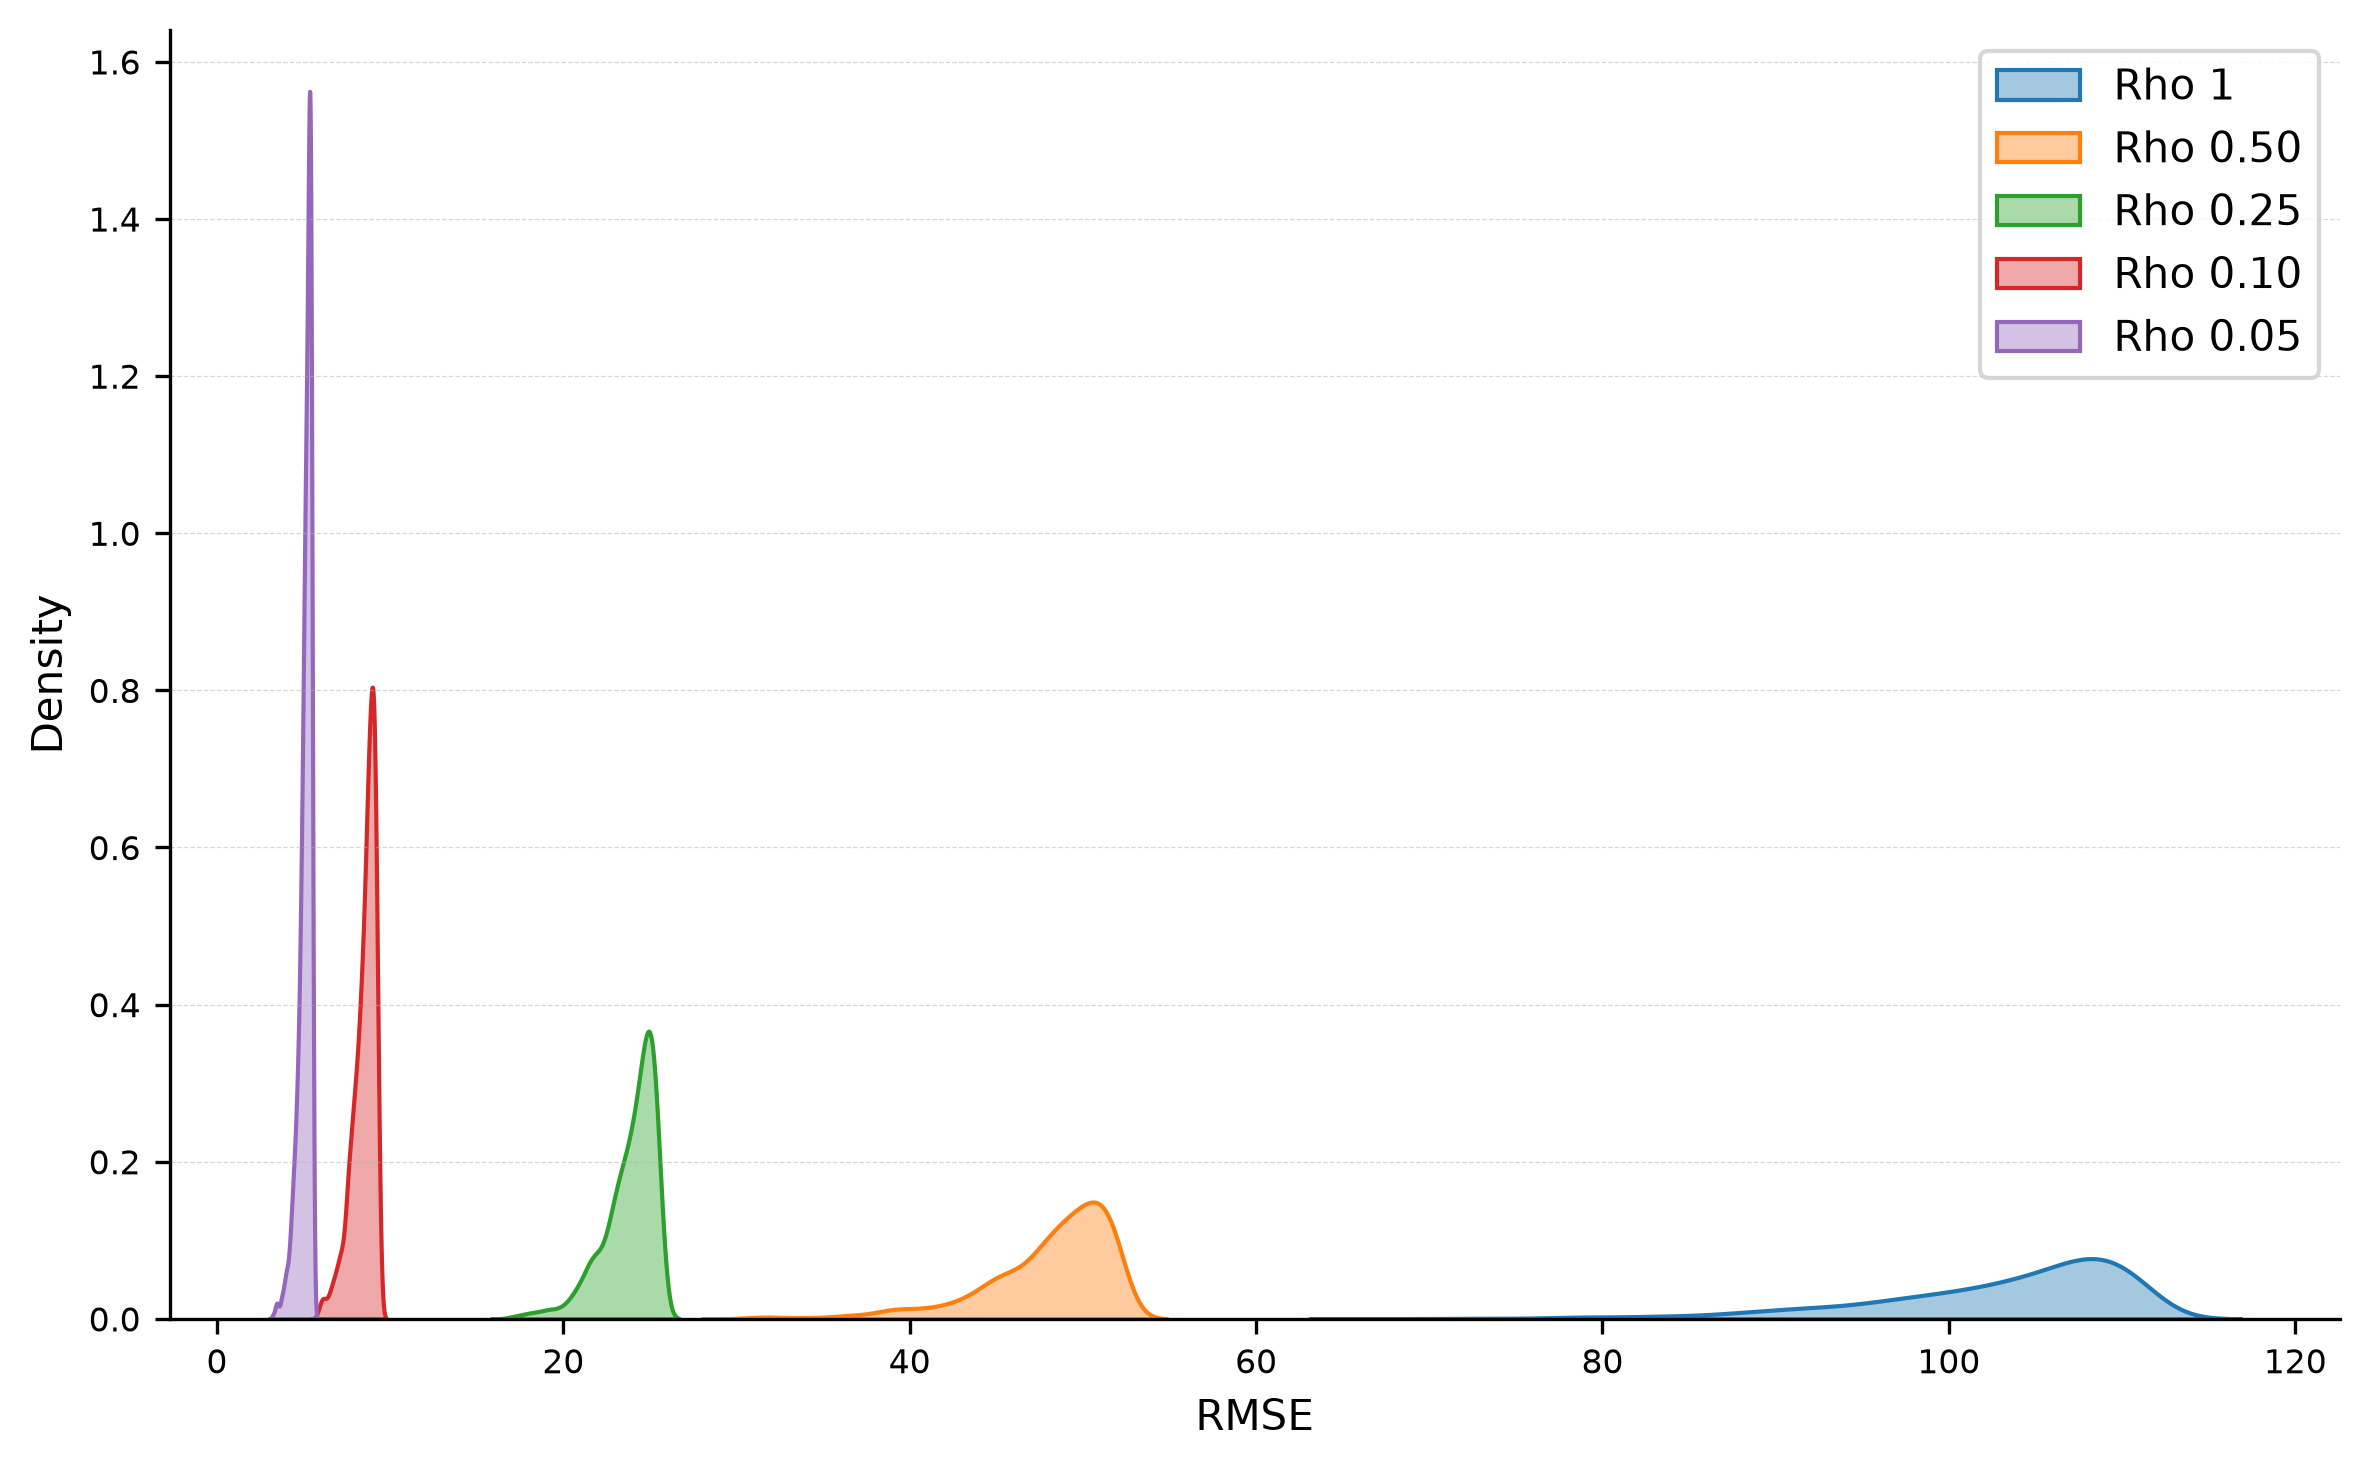

In [83]:
colors = sb.color_palette(palette=None)

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

plot_distance_distribution(abcsmc_rho_1_load[14][0].get_distances(), ax=ax,color=colors[0], kind="kde", xlabel="RMSE", label='Rho 1')

plot_distance_distribution(abcsmc_rho_5_load[14][0].get_distances(), ax=ax,color=colors[1], kind="kde", xlabel="RMSE", label='Rho 0.50')

plot_distance_distribution(abcsmc_rho_25_load[14][0].get_distances(), ax=ax,color=colors[2], kind="kde", xlabel="RMSE", label='Rho 0.25')

plot_distance_distribution(abcsmc_rho_10_load[14][0].get_distances(), ax=ax,color=colors[3], kind="kde", xlabel="RMSE", label='Rho 0.10')

plot_distance_distribution(abcsmc_rho_05_load[14][0].get_distances(), ax=ax,color=colors[4], kind="kde", xlabel="RMSE", label='Rho 0.05')


ax.legend()

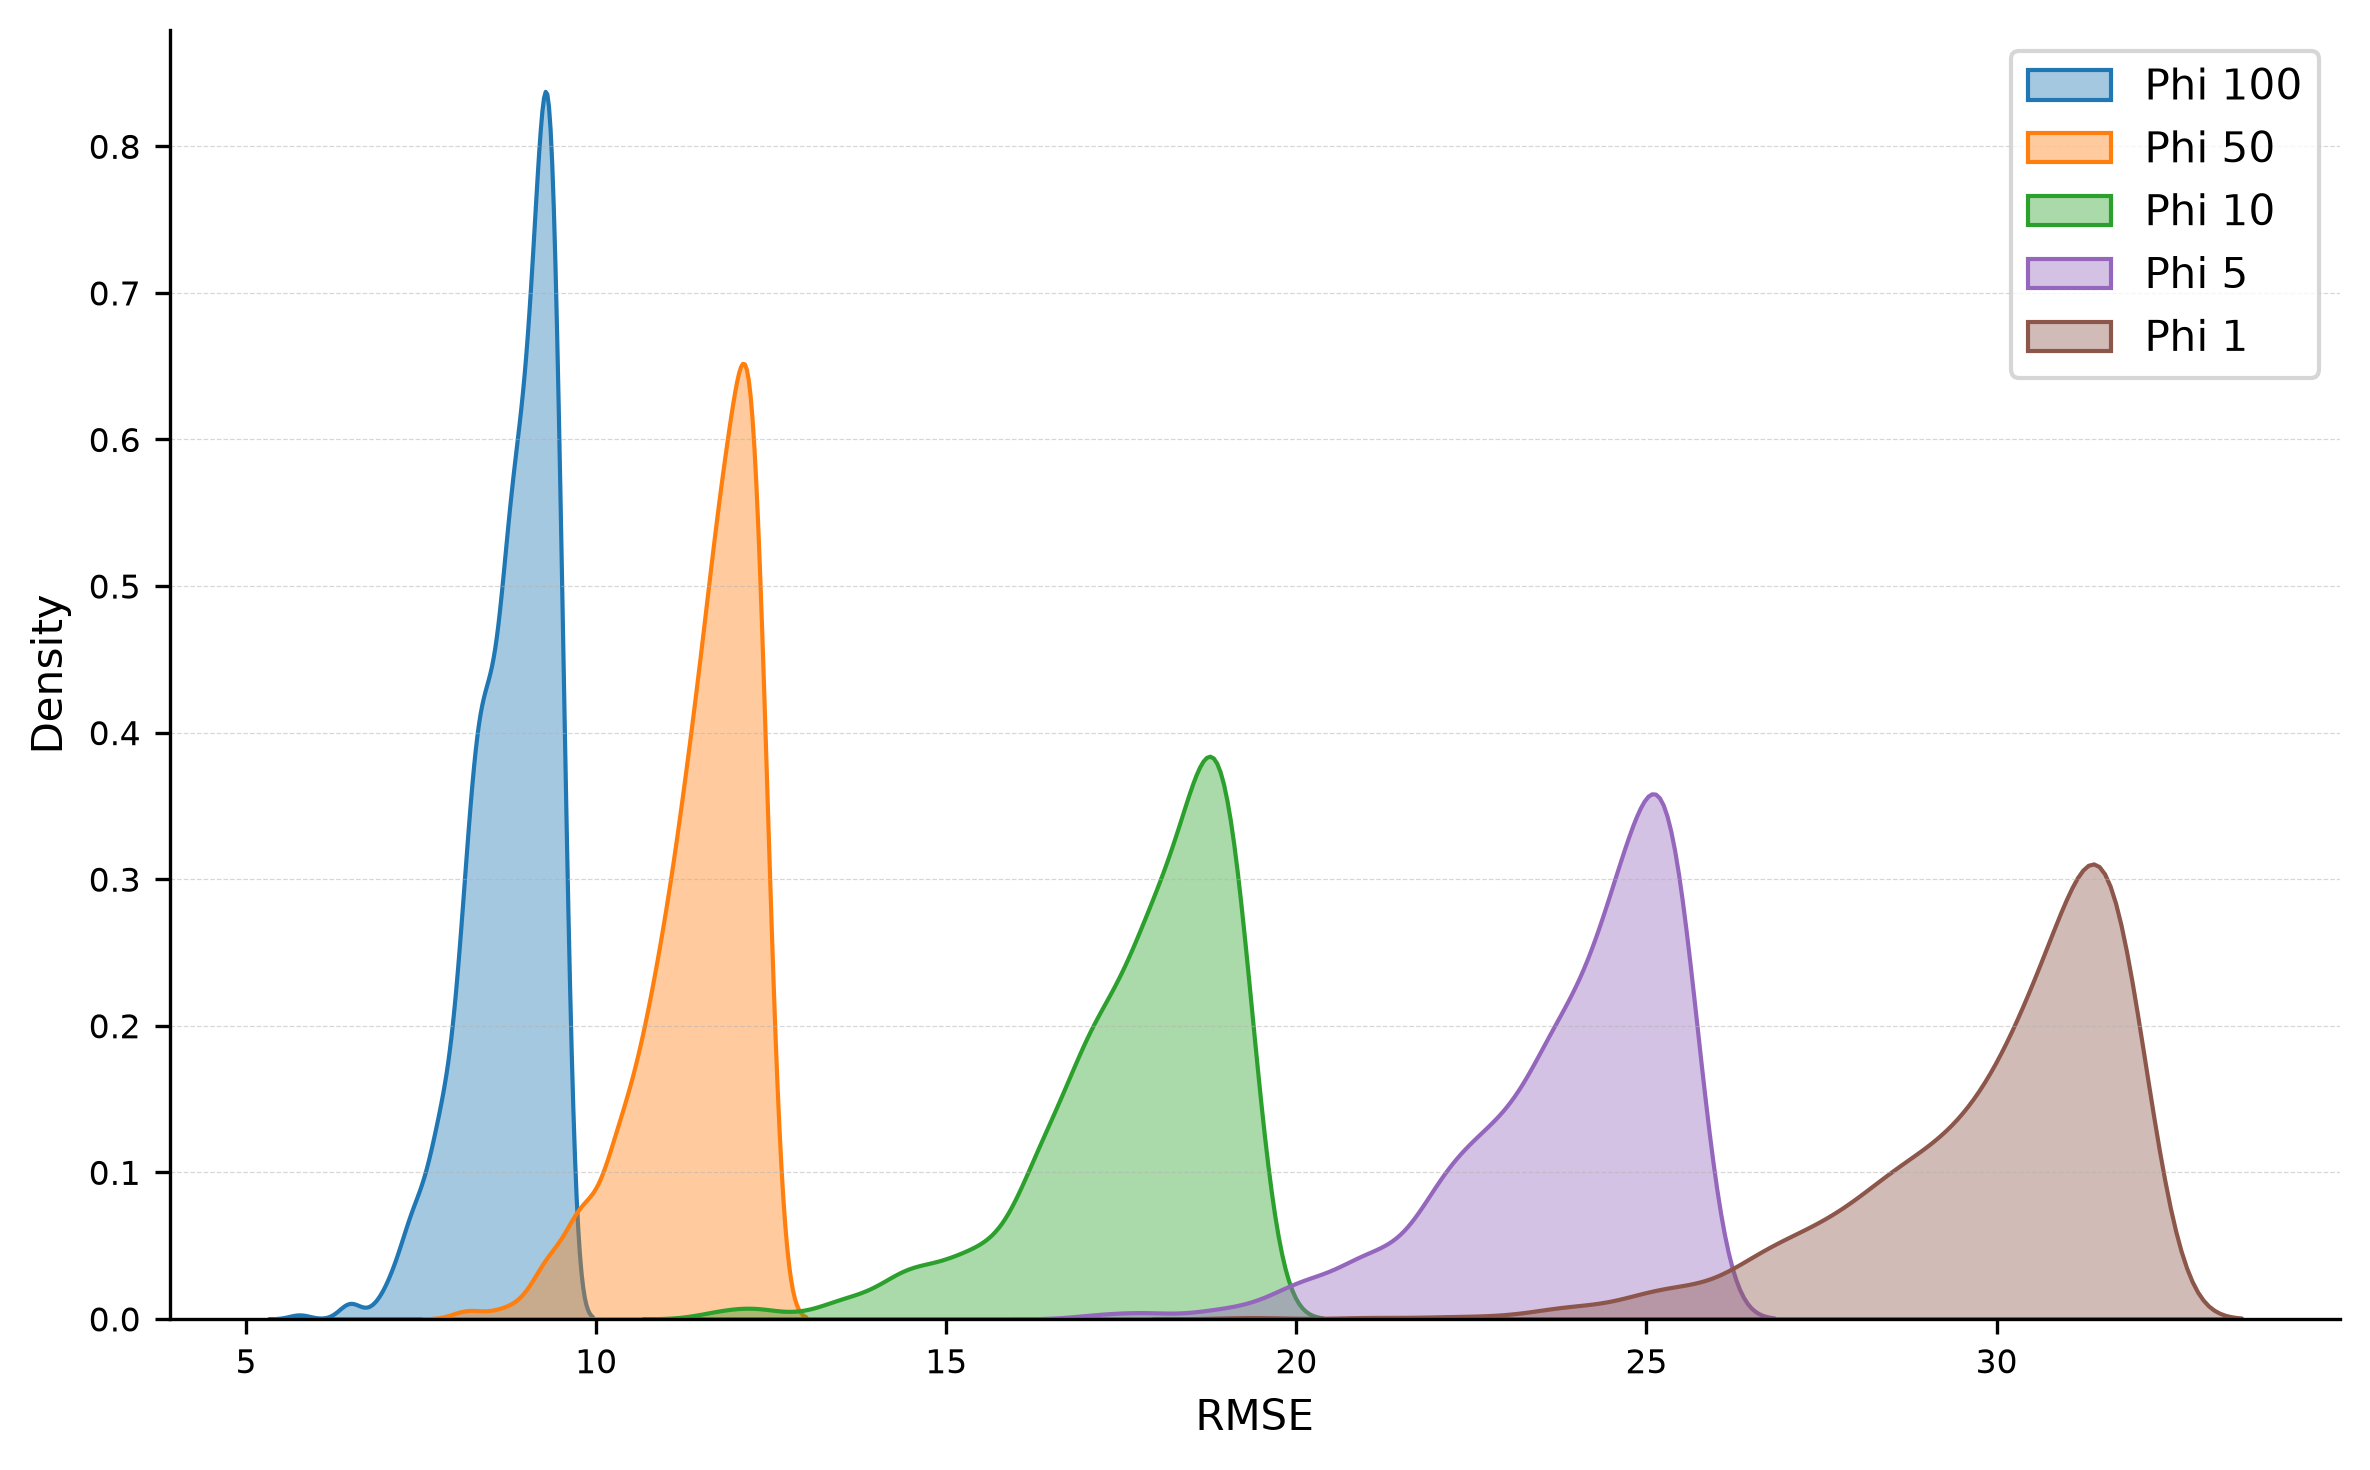

In [82]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

plot_distance_distribution(abcsmc_phi_100_load[11][0].get_distances(), ax=ax,color=colors[0], kind="kde", xlabel="RMSE", label='Phi 100')

plot_distance_distribution(abcsmc_phi_50_load[11][0].get_distances(), ax=ax,color=colors[1], kind="kde", xlabel="RMSE", label='Phi 50')

plot_distance_distribution(abcsmc_phi_10_load[11][0].get_distances(), ax=ax,color=colors[2], kind="kde", xlabel="RMSE", label='Phi 10')

plot_distance_distribution(abcsmc_rho_25_load[11][0].get_distances(), ax=ax,color=colors[4], kind="kde", xlabel="RMSE", label='Phi 5')

plot_distance_distribution(abcsmc_phi_01_load[11][0].get_distances(), ax=ax,color=colors[5], kind="kde", xlabel="RMSE", label='Phi 1')


ax.legend()

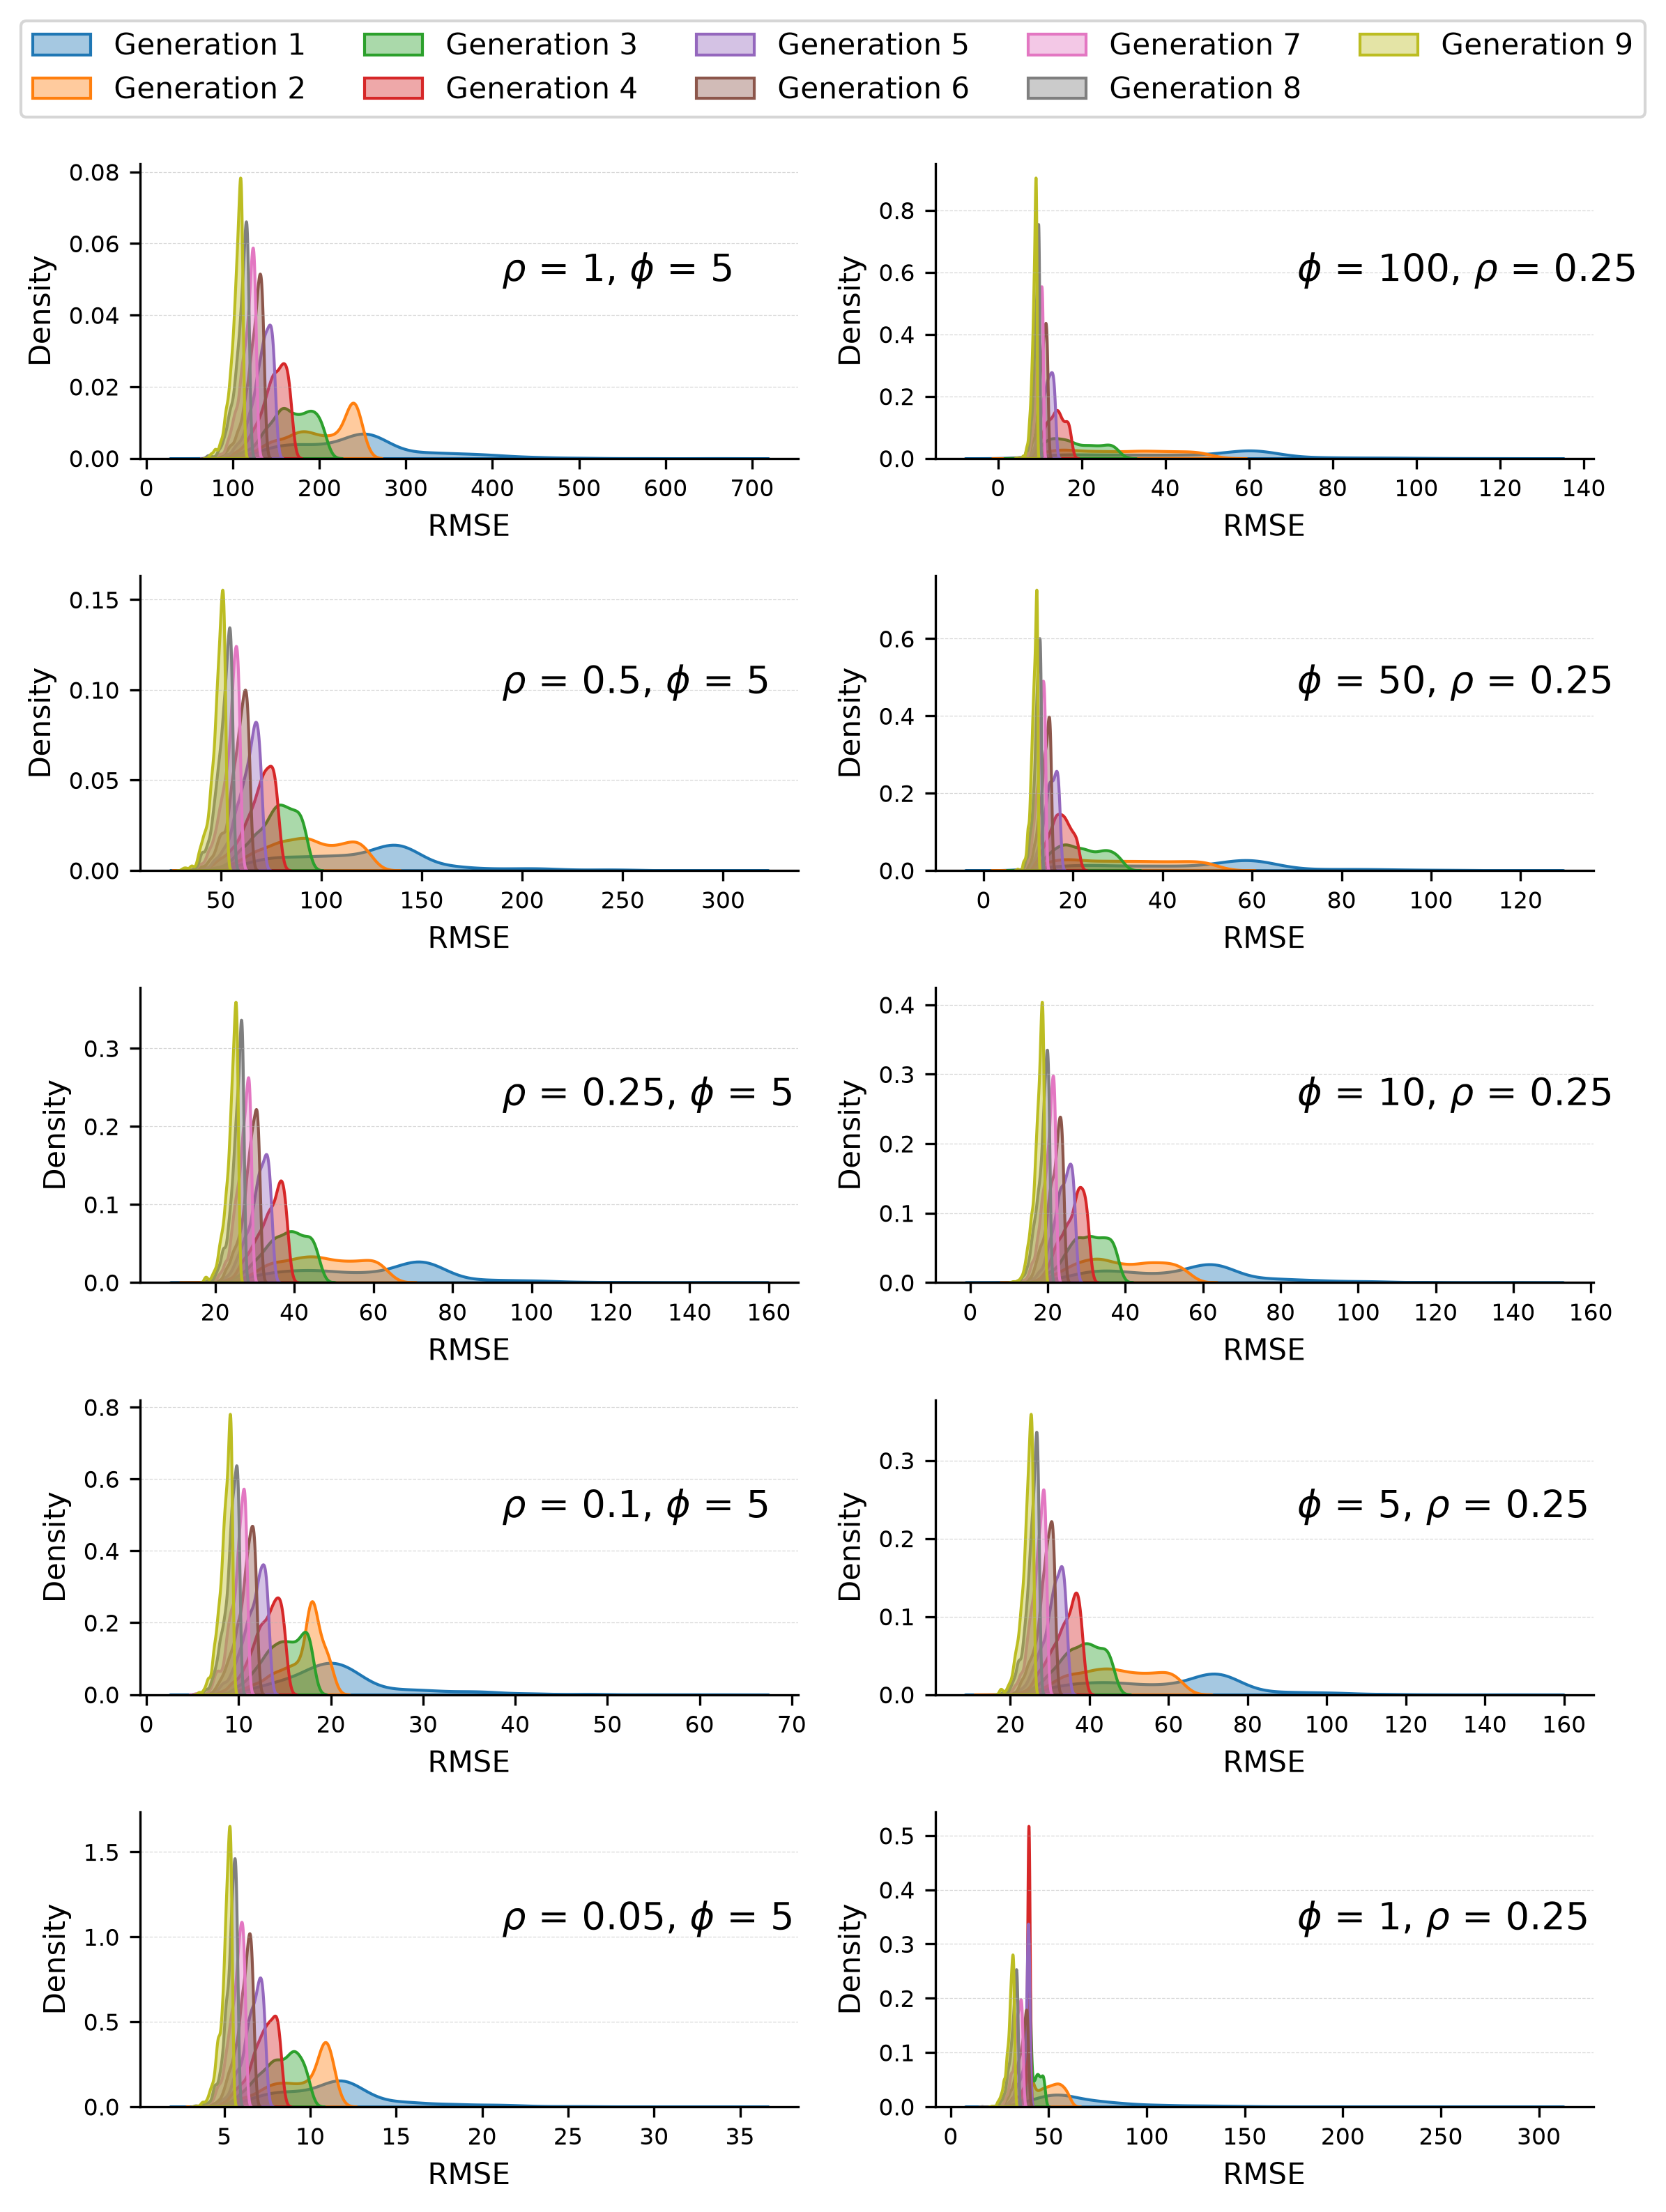

In [213]:
fig, ax = plt.subplots(5, 2, figsize=(8, 10), dpi=300)

for i in range(9):
    plot_distance_distribution(abcsmc_rho_1_load[9][0].get_distances(generation = i), ax=ax[0][0],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[0][0].text(0.55,0.60,rf'$\rho$ = {1}, $\phi$ = 5', transform=ax[0][0].transAxes, fontsize =13)


for i in range(9):
    plot_distance_distribution(abcsmc_rho_5_load[9][0].get_distances(generation = i), ax=ax[1][0],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[1][0].text(0.55,0.60,rf'$\rho$ = {0.50}, $\phi$ = 5', transform=ax[1][0].transAxes, fontsize =13)

for i in range(9):
    plot_distance_distribution(abcsmc_rho_25_load[9][0].get_distances(generation = i), ax=ax[2][0],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[2][0].text(0.55,0.60,rf'$\rho$ = {0.25}, $\phi$ = 5', transform=ax[2][0].transAxes, fontsize =13)

for i in range(9):
    plot_distance_distribution(abcsmc_rho_10_load[9][0].get_distances(generation = i), ax=ax[3][0],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[3][0].text(0.55,0.60,rf'$\rho$ = {0.10}, $\phi$ = 5', transform=ax[3][0].transAxes, fontsize =13)

for i in range(9):
    plot_distance_distribution(abcsmc_rho_05_load[9][0].get_distances(generation = i), ax=ax[4][0],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[4][0].text(0.55,0.60,rf'$\rho$ = {0.05}, $\phi$ = 5', transform=ax[4][0].transAxes, fontsize =13)

for i in range(9):
    plot_distance_distribution(abcsmc_phi_100_load[9][0].get_distances(generation = i), ax=ax[0][1],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[0][1].text(0.55,0.60,rf'$\phi$ = {100}, $\rho$ = 0.25', transform=ax[0][1].transAxes, fontsize =13)

for i in range(9):
    plot_distance_distribution(abcsmc_phi_50_load[9][0].get_distances(generation = i), ax=ax[1][1],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[1][1].text(0.55,0.60,rf'$\phi$ = {50}, $\rho$ = 0.25', transform=ax[1][1].transAxes, fontsize =13)

for i in range(9):
    plot_distance_distribution(abcsmc_phi_10_load[9][0].get_distances(generation = i), ax=ax[2][1],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[2][1].text(0.55,0.60,rf'$\phi$ = {10}, $\rho$ = 0.25', transform=ax[2][1].transAxes, fontsize =13)

for i in range(9):
    plot_distance_distribution(abcsmc_rho_25_load[9][0].get_distances(generation = i), ax=ax[3][1],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[3][1].text(0.55,0.60,rf'$\phi$ = {5}, $\rho$ = 0.25', transform=ax[3][1].transAxes, fontsize =13)

for i in range(9):
    plot_distance_distribution(abcsmc_phi_01_load[9][0].get_distances(generation = i), ax=ax[4][1],color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i+1}')

ax[4][1].text(0.55,0.60,rf'$\phi$ = {1}, $\rho$ = 0.25', transform=ax[4][1].transAxes, fontsize =13)

# Get handles and labels from one axis
handles, labels = ax[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(.5, 1.06))

plt.show()


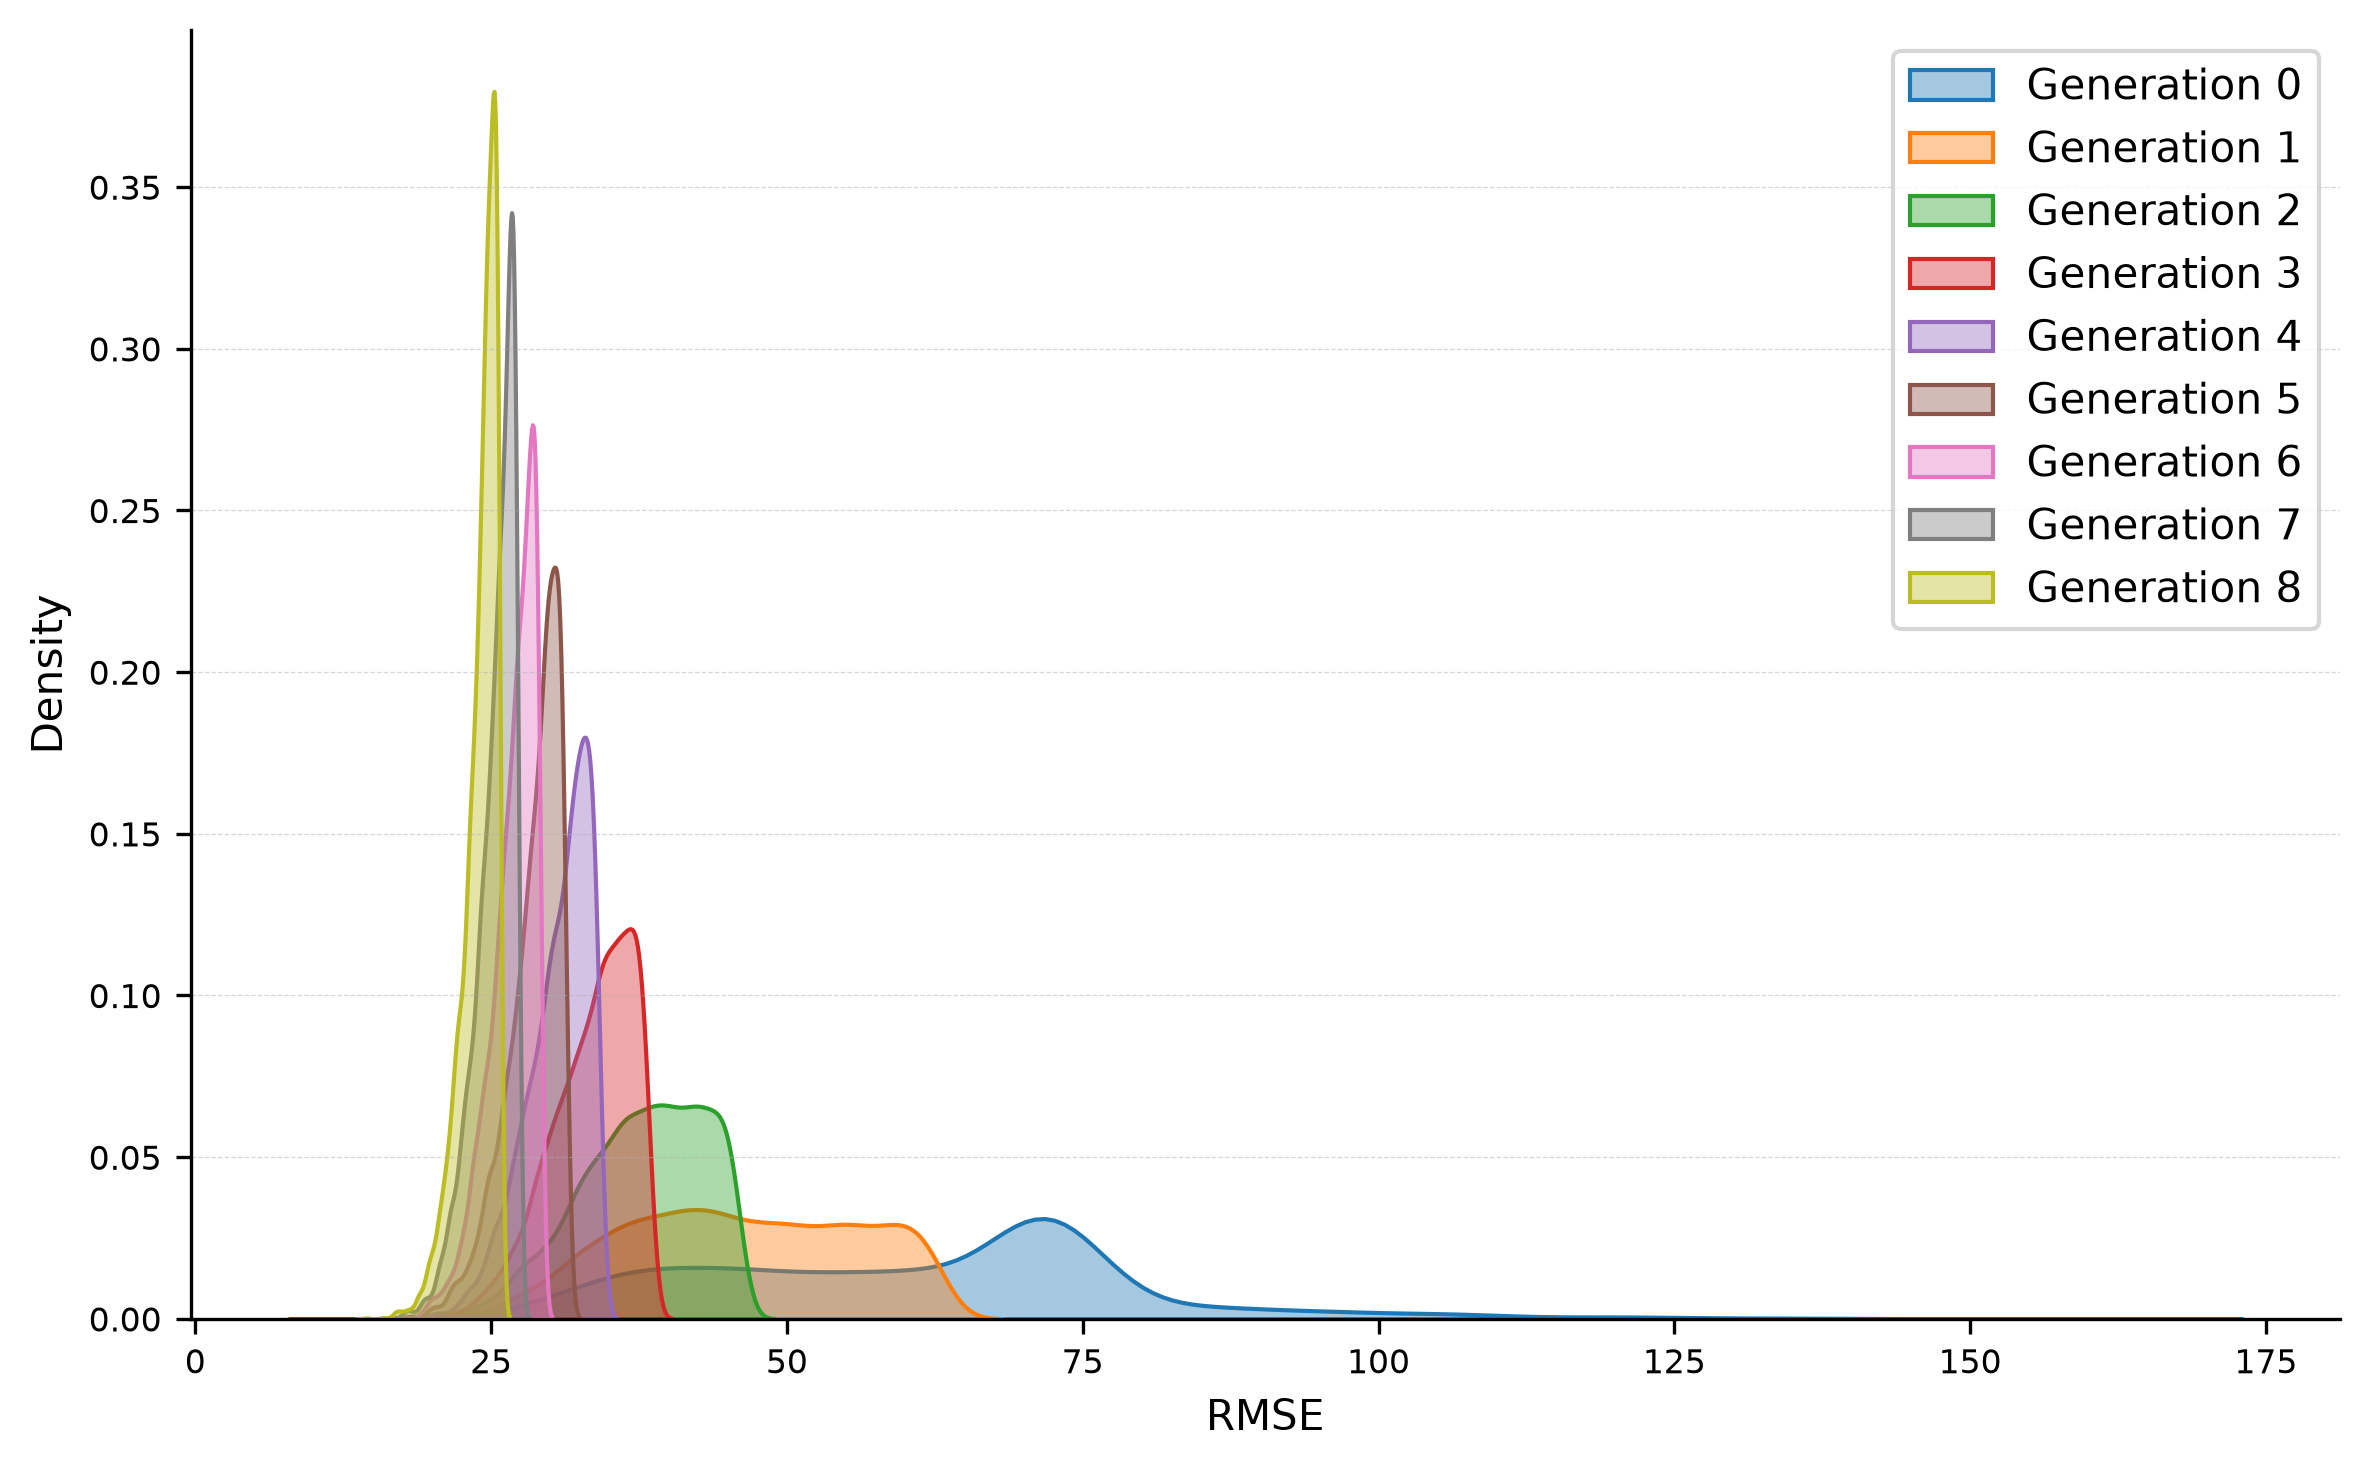

In [227]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

for i in range(9):
    plot_distance_distribution(abcsmc_5000_load[3][0].get_distances(generation = i), ax=ax,color=colors[i], kind="kde", xlabel="RMSE", label=f'Generation {i}')

ax.legend()

# Tolerance trajectory

In [120]:
print(dir(abcsmc_rho_1_load[14][0]))

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_compute_quantiles', '_get_generation', 'calibration_params', 'calibration_strategy', 'distances', 'get_calibration_quantiles', 'get_calibration_trajectories', 'get_distances', 'get_posterior_distribution', 'get_projection_quantiles', 'get_projection_trajectories', 'get_selected_trajectories', 'get_weights', 'observed_data', 'posterior_distributions', 'priors', 'projection_parameters', 'projections', 'selected_trajectories', 'weights']


In [122]:
print((abcsmc_rho_1_load[14][0]))

CalibrationResults(calibration_strategy='smc', posterior_distributions={0:          beta     gamma
0    0.503676  0.080047
1    0.301075  0.072697
2    0.421234  0.113263
3    0.296373  0.096546
4    0.166505  0.075925
..        ...       ...
995  0.461455  0.092319
996  0.298170  0.069177
997  0.463318  0.091197
998  0.710470  0.074518
999  0.502385  0.087092

[1000 rows x 2 columns], 1:          beta     gamma
0    0.675763  0.208655
1    0.371079  0.059914
2    0.452792  0.155116
3    0.377378  0.044015
4    0.135009  0.116594
..        ...       ...
995  0.274814  0.076849
996  0.558780  0.091686
997  0.127972  0.085001
998  0.395039  0.040616
999  0.356517  0.050199

[1000 rows x 2 columns], 2:          beta     gamma
0    0.302736  0.015701
1    0.515837  0.150753
2    0.386839  0.115285
3    0.487632  0.107744
4    0.360654  0.097900
..        ...       ...
995  0.400320  0.104781
996  0.361698  0.002088
997  0.348909  0.056887
998  0.356018  0.026539
999  0.337487  0.039295

[1

# Plot Tolerance Trajectory

In [137]:
print(max((abcsmc_rho_1_load[14][0]).distances[8]))

111.41714410269185


In [146]:
# Extract tolerance trajectories (RHO)
rho_1_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_rho_1_load[i][0]).distances[j]))
    rho_1_ep.append(gen)
rho_1_ep = np.array(rho_1_ep)

rho_5_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_rho_5_load[i][0]).distances[j]))
    rho_5_ep.append(gen)
rho_5_ep = np.array(rho_5_ep)

rho_25_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_rho_25_load[i][0]).distances[j]))
    rho_25_ep.append(gen)
rho_25_ep = np.array(rho_25_ep)

rho_10_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_rho_10_load[i][0]).distances[j]))
    rho_10_ep.append(gen)
rho_10_ep = np.array(rho_10_ep)

rho_05_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_rho_05_load[i][0]).distances[j]))
    rho_05_ep.append(gen)
rho_05_ep = np.array(rho_05_ep)

In [147]:
# Extract tolerance trajectories (PHI)
phi_100_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_phi_100_load[i][0]).distances[j]))
    phi_100_ep.append(gen)
phi_100_ep = np.array(phi_100_ep)

phi_50_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_phi_50_load[i][0]).distances[j]))
    phi_50_ep.append(gen)
phi_50_ep = np.array(phi_50_ep)

phi_10_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_phi_10_load[i][0]).distances[j]))
    phi_10_ep.append(gen)
phi_10_ep = np.array(phi_10_ep)

phi_05_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_rho_25_load[i][0]).distances[j]))
    phi_05_ep.append(gen)
phi_05_ep = np.array(phi_05_ep)

phi_01_ep = []
for i in range(15):
    gen = []
    for j in range(9):
        gen.append(max((abcsmc_phi_01_load[i][0]).distances[j]))
    phi_01_ep.append(gen)
phi_01_ep = np.array(phi_01_ep)

/var/folders/78/7v9nz15x7059dykx93846qzm0000gn/T/ipykernel_31370/3101973400.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=13)


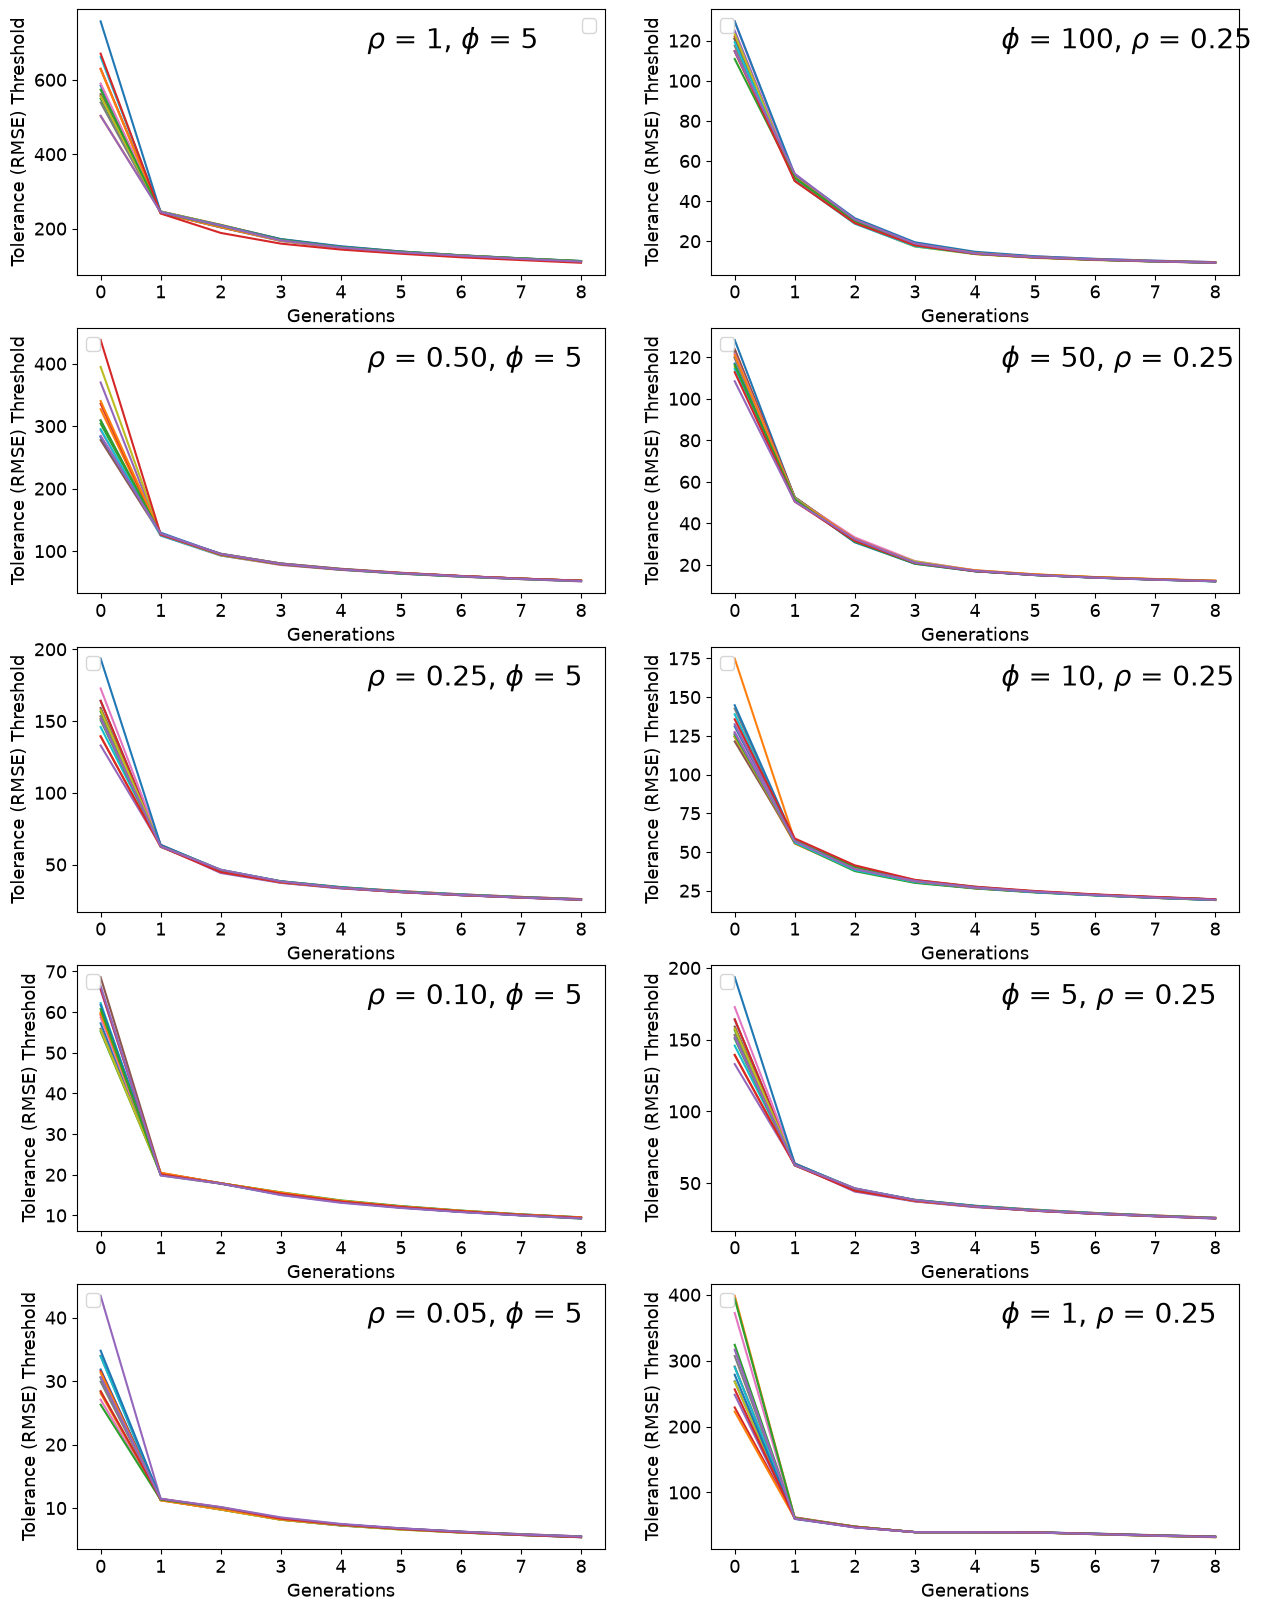

In [177]:
fig, axes = plt.subplots(5,2)

for i in range(15):
    axes[0][0].plot(rho_1_ep[i])
axes[0][0].text(0.55,0.85,rf'$\rho$ = 1, $\phi$ = 5', transform=axes[0][0].transAxes, fontsize = 20)


for i in range(15):
    axes[1][0].plot(rho_5_ep[i])
axes[1][0].text(0.55,0.85,rf'$\rho$ = 0.50, $\phi$ = 5', transform=axes[1][0].transAxes, fontsize = 20)

for i in range(15):
    axes[2][0].plot(rho_25_ep[i])
axes[2][0].text(0.55,0.85,rf'$\rho$ = 0.25, $\phi$ = 5', transform=axes[2][0].transAxes, fontsize = 20)

for i in range(15):
    axes[3][0].plot(rho_10_ep[i])
axes[3][0].text(0.55,0.85,rf'$\rho$ = 0.10, $\phi$ = 5', transform=axes[3][0].transAxes, fontsize = 20)

for i in range(15):
    axes[4][0].plot(rho_05_ep[i])
axes[4][0].text(0.55,0.85,rf'$\rho$ = 0.05, $\phi$ = 5', transform=axes[4][0].transAxes, fontsize = 20)

for i in range(15):
    axes[0][1].plot(phi_100_ep[i])
axes[0][1].text(0.55,0.85,rf'$\phi$ = 100, $\rho$ = 0.25', transform=axes[0][1].transAxes, fontsize = 20)

for i in range(15):
    axes[1][1].plot(phi_50_ep[i])
axes[1][1].text(0.55,0.85,rf'$\phi$ = 50, $\rho$ = 0.25', transform=axes[1][1].transAxes, fontsize = 20)

for i in range(15):
    axes[2][1].plot(phi_10_ep[i])
axes[2][1].text(0.55,0.85,rf'$\phi$ = 10, $\rho$ = 0.25', transform=axes[2][1].transAxes, fontsize = 20)

for i in range(15):
    axes[3][1].plot(phi_05_ep[i])
axes[3][1].text(0.55,0.85,rf'$\phi$ = 5, $\rho$ = 0.25', transform=axes[3][1].transAxes, fontsize = 20)

for i in range(15):
    axes[4][1].plot(phi_01_ep[i])
axes[4][1].text(0.55,0.85,rf'$\phi$ = 1, $\rho$ = 0.25', transform=axes[4][1].transAxes, fontsize = 20)


fig.set_figheight(20)
fig.set_figwidth(15)

for ax in axes.flat:
    ax.set_ylabel('Tolerance (RMSE) Threshold', fontsize = 13)
    ax.legend(fontsize=13)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_xlabel('Generations',  fontsize = 13)


plt.show()